## Plot MD changes across sessions 
# Feb2026 - FF_dwi_drift

In [ ]:
"""
SET UP lib. and main flags
---------------------------------------------
DEBUGGING / LOGGING FLAGS
"""
import os
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import subprocess

### set path for fsl and freesurfer
fsl_path=r"/usr/local/fsl"

### set path to reference images 
# 1mm 
refT11mm=r"/usr/local/fsl/data/standard/MNI152_T1_1mm.nii.gz"                             # MNI 1mm image 
refT11mmBrain=r"/usr/local/fsl/data/standard/MNI152_T1_1mm_brain.nii.gz"              # MNI 1mm brain extraction

# refT11mmBrainMask = "$fsl_path/data/standard/MNI152_T1_1mm_brain_mask_dil.nii.gz"   # for T1 and T2, _dil to be conservative with final brain mask
refT11mmBrainMask=r"/usr/local/fsl/data/standard/MNI152_T1_1mm_brain_mask.nii.gz"        # for T1 and T2, _dil to be conservative with final brain mask
refT11mmBrainMaskTight=r"/usr/local/fsl/data/standard/MNI152_T1_1mm_brain_mask.nii.gz"

# 2mm 
refT12mm=r"/usr/local/fsl/data/standard/MNI152_T1_2mm.nii.gz"                         # MNI 2mm T1 image 
refT12mmBrain=r"/usr/local/fsl/data/standard/MNI152_T1_2mm_brain.nii.gz"                 # MNI 2mm brain extraction
refT12mmBrainMask=r"/usr/local/fsl/data/standard/MNI152_T1_2mm_brain_mask_dil.nii.gz"     # for T1 and T2, _dil to be conservative with final brain mask

### path to ANTs templates - Usefull only fot T1w preprocessing
ants_template_path=r"/home/malberti/Unix_Folders/MRI_templates/OASIS30ANTs"
ants_template=r"tpl-OASIS30ANTs_res-01_desc-brain_T1w.nii.gz"
ants_prior=r"tpl-OASIS30ANTs_res-01_label-brain_probseg.nii.gz" 

## SET WORKING DIRECTORY
prj_path=r"/home/malberti/wks14/temp/FF_DWI_Drift" # main BIDS path /home/malberti/Unix_Folders/Sweep/Pilot/SW005
project="sub-" #Common name for folders and files, for example all my sweep files are named as "sw001_ss1_dwi_AP.nii || sw001_ss1_T1w.nii"
script=r'/home/malberti/wks14/temp/FF_DWI_Drift/Script'


vp = 15
sessions = ["ses-01","ses-03","ses-04","ses-05",
            "ses-06","ses-07","ses-08","ses-09","ses-10",
            "ses-11","ses-12","ses-13", "ses-14","ses-15","ses-16", "ses-17", 
            "ses-18","ses-19", "ses-20", "ses-21","ses-22" ]

In [ ]:
metric="MD"

lthr=0.0001
uthr=0.1
vps=(15, 16, 17 , 18, 19, 20 ,21, 22, 24, 24, 25, 26, 27, 28, 29, 30, 31,32)

for vp in vps:   
    vp= 23 
    id = f"sub-{vp:02d}"   # id: standard subject ID (sub-XX)
    derivatives = os.path.join(prj_path, "derivatives", id)   # Path to derivative folder for this participant & session

    sessions   = sorted( f for f in os.listdir(os.path.join(derivatives)) if f.startswith("ses-")
    )

    for session in sessions:    # Loop over sessions for this participant
        subjid = f"{id}_{session}"     # Standardized subject-session identifier 
        
        derivatives = os.path.join(prj_path, "derivatives", id, session)   # Path to derivative folder for this participant & session

        eddy_path=os.path.join(derivatives, "dwi","eddy")
        Dwmri_index=os.path.join(derivatives, "dwi","index")
        Dtifit_out=os.path.join(Dwmri_index,"Tensor")

        mask=os.path.join(eddy_path,f"{subjid}_unwarped_mask.nii.gz")  #Orig. mask 
        ero_mask=os.path.join(Dwmri_index,f"{subjid}_unwarped_mask_ero6.nii.gz")

        ## First erode the mask by 6 voxels and remove some slices

        
        subprocess.run(f"fslmaths {mask} -ero -ero -ero -ero {ero_mask} ",shell=True)
        subprocess.run(f"fslroi {ero_mask} {ero_mask} 5 110 5 110 3 70",shell=True)
        print(subjid)
        
    # Plot MD 
    # Att acquisition time: "AcquisitionTime": "15:12:5.692500",

/tmp/ipykernel_1172511/1779752761.py:46: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  mask_resampled = resample_to_img(mask_img, md_img,
/tmp/ipykernel_1172511/1779752761.py:46: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mask_resampled = resample_to_img(mask_img, md_img,


ses-07 failed: No such file or no access: '/home/malberti/wks14/temp/FF_DWI_Drift/derivatives/sub-32/ses-07/dwi/index/Tensor/sub-32_ses-07_prep_MD.nii'
ses-08 failed: No such file or no access: '/home/malberti/wks14/temp/FF_DWI_Drift/derivatives/sub-32/ses-08/dwi/index/Tensor/sub-32_ses-08_prep_MD.nii'
ses-09 failed: No such file or no access: '/home/malberti/wks14/temp/FF_DWI_Drift/derivatives/sub-32/ses-09/dwi/index/Tensor/sub-32_ses-09_prep_MD.nii'
ses-10 failed: No such file or no access: '/home/malberti/wks14/temp/FF_DWI_Drift/derivatives/sub-32/ses-10/dwi/index/Tensor/sub-32_ses-10_prep_MD.nii'
ses-11 failed: No such file or no access: '/home/malberti/wks14/temp/FF_DWI_Drift/derivatives/sub-32/ses-11/dwi/index/Tensor/sub-32_ses-11_prep_MD.nii'
ses-12 failed: No such file or no access: '/home/malberti/wks14/temp/FF_DWI_Drift/derivatives/sub-32/ses-12/dwi/index/Tensor/sub-32_ses-12_prep_MD.nii'
ses-13 failed: No such file or no access: '/home/malberti/wks14/temp/FF_DWI_Drift/deriva

/tmp/ipykernel_1172511/1779752761.py:76: RuntimeWarning: All-NaN slice encountered
  medians = [np.nanmedian(md) for md in all_md_values]
/tmp/ipykernel_1172511/1779752761.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


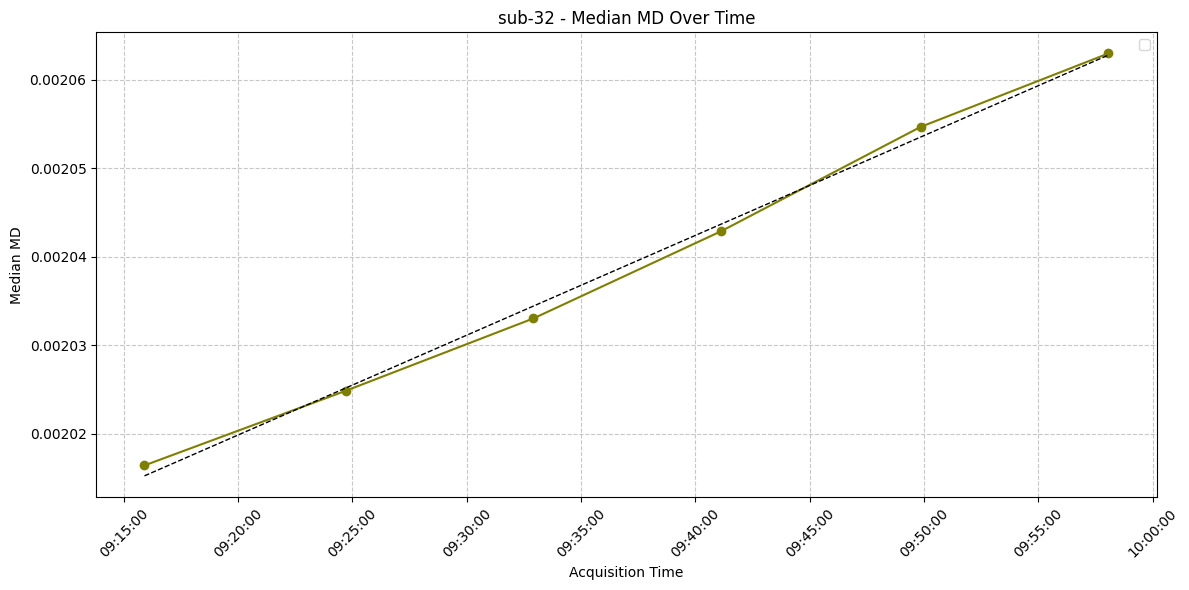

In [8]:
import os
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn.image import resample_to_img
from datetime import datetime
import matplotlib.dates as mdates

# -----------------------------
# SETTINGS
# -----------------------------
vp=32
id = f"sub-{vp:02d}"   # subject ID

all_md_values = []
acq_times_str = []
metric="MD"

# -----------------------------
# LOOP OVER SESSIONS
# -----------------------------
for session in sessions:
    try:
        subjid = f"{id}_{session}"
        derivatives = os.path.join(prj_path, "derivatives", id, session)

        Dwmri_index = os.path.join(derivatives, "dwi", "index")
        Dtifit_out = os.path.join(Dwmri_index, "Tensor")

        mask_path = os.path.join(derivatives, "dwi", "eddy",
                                 f"{subjid}_unwarped_mask.nii")

        map_path = os.path.join(Dtifit_out,
                                f"{subjid}_prep_{metric}.nii")

        json_path = os.path.join(prj_path, "rawdata",
                                 id, session, "dwi",
                                 f"{subjid}_dir-AP_part-mag_dwi.json")

        # ---- Load images ----
        md_img = nib.load(map_path)
        mask_img = nib.load(mask_path)

        # ---- Resample mask to MD space ----
        mask_resampled = resample_to_img(mask_img, md_img,
                                         interpolation="nearest")

        md_data = md_img.get_fdata()
        mask_data = mask_resampled.get_fdata().astype(bool)

        # ---- Apply mask ----
        md_masked = md_data[mask_data]

        # ---- Threshold ----
        md_masked = md_masked[(md_masked > 0) & (md_masked < 1)]#md_masked[(md_masked > 0.0001) & (md_masked < 0.005)]

        if len(md_masked) == 0:
            raise ValueError("No voxels after masking")

        all_md_values.append(md_masked)

        # ---- Extract Acquisition Time ----
        with open(json_path, "r") as f:
            meta = json.load(f)
        acq_times_str.append(meta.get("AcquisitionTime", None))

    except Exception as e:
        print(f"{session} failed: {e}")
        all_md_values.append(np.array([np.nan]))
        acq_times_str.append(None)

# -----------------------------
# COMPUTE MEDIAN MD
# -----------------------------
medians = [np.nanmedian(md) for md in all_md_values]

# -----------------------------
# CONVERT ACQUISITION TIMES TO DATETIME OBJECTS
# -----------------------------
acq_times_dt = []
for t_str in acq_times_str:
    try:
        acq_times_dt.append(datetime.strptime(t_str, "%H:%M:%S.%f"))
    except:
        acq_times_dt.append(np.nan)  # keep NaN for missing times

# Remove sessions with missing times for plotting
x_times = [t for t, m in zip(acq_times_dt, medians) if t is not np.nan]
y_medians = [m for t, m in zip(acq_times_dt, medians) if t is not np.nan]

# -----------------------------
# COMPUTE TREND LINE
# -----------------------------
x_float = mdates.date2num(x_times)
coef = np.polyfit(x_float, y_medians, 1)
trend_median = np.poly1d(coef)(x_float)

# -----------------------------
# PLOT MEDIAN MD
# -----------------------------
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(x_times, y_medians,
        marker='o', linewidth=1.5,
        color='olive')

ax.plot(x_times, trend_median,
        linestyle='--', linewidth=1,
        color='black')

# -----------------------------
# FORMAT X AXIS AS TIME
# -----------------------------
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

# -----------------------------
# GRID, LABELS, LEGEND
# -----------------------------
ax.grid(True, linestyle='--', alpha=0.7)
plt.xlabel("Acquisition Time")
plt.ylabel(f"Median {metric}")
plt.title(f"{id} - Median {metric} Over Time")
plt.legend()
plt.tight_layout()
plt.show()

## Sub-007 i made this variant to this script because this acquistion need to compare sms=1 and sms=2 (i asked chat gpt to comment and clean it)

In [ ]:
import os
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn.image import resample_to_img
from datetime import datetime
import matplotlib.dates as mdates

# -----------------------------
# SETTINGS
# -----------------------------
vp=7
id = f"sub-{vp:02d}"   # subject ID

all_md_values = []
acq_times_str = []
metric="FA"

sessions_sms1 = ["ses-02", "ses-03", "ses-06", "ses-07","ses-10", "ses-11", "ses-14", "ses-15","ses-18", "ses-19", "ses-22", "ses-23"]# ,"ses-25", "ses-26", "ses-27", "ses-28"]
sessions_sms2 = ["ses-01", "ses-04", "ses-05", "ses-08","ses-09", "ses-12", "ses-13", "ses-16","ses-17", "ses-20", "ses-21", "ses-24"]# ,"ses-25", "ses-26", "ses-27", "ses-28"]


# -----------------------------
# SMS1
# -----------------------------
all_md_values_sms1 = []
acq_times_str_sms1 = []

for session in sessions_sms1:
    subjid = f"{id}_{session}"
    derivatives = os.path.join(prj_path, "derivatives", id, session)

    Dwmri_index = os.path.join(derivatives, "dwi", "index")
    Dtifit_out = os.path.join(Dwmri_index, "Tensor")

    mask_path =os.path.join("/home/malberti/wks14/temp/FF_DWI_Drift/sub-07_PCA_drift", f"{id}_cube_mask.nii.gz") #os.path.join(Dwmri_index, f"{subjid}_unwarped_mask_ero6.nii.gz")

    map_path = os.path.join(Dtifit_out,
                            f"{subjid}_prep_{metric}.nii.gz")

    json_path = os.path.join(prj_path, "rawdata",
                                id, session, "dwi",
                                f"{subjid}_dir_AP_part_mag_dwi.json")

    md_img = nib.load(map_path)
    mask_img = nib.load(mask_path)

    mask_resampled = resample_to_img(mask_img, md_img,
                                        interpolation="nearest")

    md_data = md_img.get_fdata()
    mask_data = mask_resampled.get_fdata().astype(bool)

    md_masked = md_data[mask_data]
    md_masked = md_masked[(md_masked > 0) & (md_masked < 1)]

    all_md_values_sms1.append(md_masked)

    with open(json_path, "r") as f:
        meta = json.load(f)

    acq_times_str_sms1.append(meta.get("AcquisitionTime", None))


medians_sms1 = [np.nanmedian(md) for md in all_md_values_sms1]

acq_times_dt_sms1 = []
for t_str in acq_times_str_sms1:
    acq_times_dt_sms1.append(datetime.strptime(t_str, "%H:%M:%S.%f"))
   
x1 = [t for t, m in zip(acq_times_dt_sms1, medians_sms1) if t is not np.nan]
y1 = [m for t, m in zip(acq_times_dt_sms1, medians_sms1) if t is not np.nan]

x1_float = mdates.date2num(x1)
coef1 = np.polyfit(x1_float, y1, 1)
trend1 = np.poly1d(coef1)(x1_float)


# -----------------------------
# SMS2
# -----------------------------
all_md_values_sms2 = []
acq_times_str_sms2 = []

for session in sessions_sms2:
    subjid = f"{id}_{session}"
    derivatives = os.path.join(prj_path, "derivatives", id, session)

    Dwmri_index = os.path.join(derivatives, "dwi", "index")
    Dtifit_out = os.path.join(Dwmri_index, "Tensor")

    mask_path =mask_path =os.path.join("/home/malberti/wks14/temp/FF_DWI_Drift/sub-07_PCA_drift", f"{id}_cube_mask.nii.gz") #os.path.join(Dwmri_index,f"{subjid}_unwarped_mask_ero6.nii.gz")

    map_path = os.path.join(Dtifit_out,
                            f"{subjid}_prep_{metric}.nii.gz")

    json_path = os.path.join(prj_path, "rawdata",
                                id, session, "dwi",
                                f"{subjid}_dir_AP_part_mag_dwi.json")

    md_img = nib.load(map_path)
    mask_img = nib.load(mask_path)

    mask_resampled = resample_to_img(mask_img, md_img,
                                        interpolation="nearest")

    md_data = md_img.get_fdata()
    mask_data = mask_resampled.get_fdata().astype(bool)

    md_masked = md_data[mask_data]
    md_masked = md_masked[(md_masked > 0) & (md_masked < 1)]

    all_md_values_sms2.append(md_masked)

    with open(json_path, "r") as f:
        meta = json.load(f)

    acq_times_str_sms2.append(meta.get("AcquisitionTime", None))


medians_sms2 = [np.nanmedian(md) for md in all_md_values_sms2]

acq_times_dt_sms2 = []
for t_str in acq_times_str_sms2:
    acq_times_dt_sms2.append(datetime.strptime(t_str, "%H:%M:%S.%f"))
   
x2 = [t for t, m in zip(acq_times_dt_sms2, medians_sms2) if t is not np.nan]
y2 = [m for t, m in zip(acq_times_dt_sms2, medians_sms2) if t is not np.nan]

x2_float = mdates.date2num(x2)
coef2 = np.polyfit(x2_float, y2, 1)
trend2 = np.poly1d(coef2)(x2_float)


# -----------------------------
# PLOT BOTH
# -----------------------------
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(x1, y1, marker='o', color='olive', label='SMS1')
#ax.plot(x1, trend1, linestyle='--', color='olive')

ax.plot(x2, y2, marker='o', color='darkred', label='SMS2')
#ax.plot(x2, trend2, linestyle='--', color='darkred')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xticks(rotation=45)

ax.grid(True, linestyle='--', alpha=0.7)
plt.xlabel("Acquisition Time")
plt.ylabel(f"Median {metric}")
plt.title(f"{id} - Median {metric} Over Time")

plt.legend()
plt.tight_layout()
plt.show()